In [ ]:
from Model import *
from Dataset import *
from Perfomance import *

In [2]:
import warnings
warnings.filterwarnings(action='ignore')

There is all testing for modules provided

In [5]:
#Testing functions of Model class
model = CNNLSTM()

model.compile(optimizer='SGD', loss={
        'binary': binary_loss_fn,
        'multiclass': multiclass_loss_fn
    })

model([np.random.rand(5,8,8,112), np.random.rand(5)])
#model.summary()
ar = np.load(f'{DATA_DIR}/test.npz')
positions = ar['x']; evals = ar['evals'].astype(np.float32); target = ar['y']
#print(positions.shape, evals.shape, target.shape)
with tf.GradientTape() as tape:
    preds = model.binary_call((positions, evals))
    loss = binary_loss_fn(target, preds)
print(loss)
print(target)
print(f"Probas for class 1 {preds[:, 1]}")

tf.Tensor(0.994782, shape=(), dtype=float32)
[[0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
Probas for class 1 [0.0517131  0.09567361 0.09567361 0.09567361 0.99656826 0.24835193
 0.09567361 0.03633894 0.09567366 0.03031184]


I0000 00:00:1777215097.110604   43641 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


Batch 0 | Loss 21.792556762695312 | Balanced Accuracy 0.5


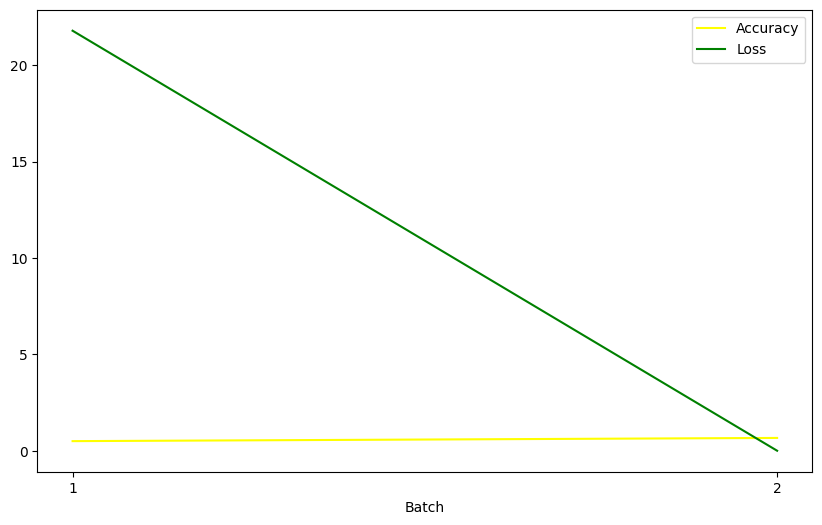

In [6]:
#Testing Dataset
ds = build_binary_dataset(10)
model.training_run(ds, batch_size=5)

In [5]:
#Testing Perfomance
batch_size=10

positions = np.random.randn(batch_size,4,8,8,112)
evals = np.random.randn(batch_size,4)
target = np.zeros(shape=(batch_size,num_classes))
for i in range(batch_size):
    if np.random.rand()<=class_weight:
        class_value = num_classes-1
    else:
        class_value = np.random.randint(low=0, high=num_classes-1)
    target[i, class_value]=1

'''ar = np.load("data/batch0.npz")
positions = ar['x'][:batch_size]
target = ar['y'][:batch_size]
    
evals = ar['evals'][:batch_size]
print(positions.shape, target.shape, evals.shape)
target = np.append(target, np.zeros((target.shape[0], 1)), axis=1) #For dimensionality match'''
bin_target = tf.cast(tf.equal(target[:, -1], 0), tf.int8)
model.only_bin = False
with tf.GradientTape() as tape:
    preds = model((positions, evals))
    binary_loss = binary_loss_fn(bin_target, preds['binary'])
    multiclass_loss = multiclass_loss_fn(target, preds['multiclass'])
    loss = binary_loss+multiclass_loss

grad = tape.gradient(loss, model.trainable_variables)
#print(f"\n\n Preds are {preds} \n\n")

binary_auc = BinaryAUCMetric()
binary_auc.update_state(target, preds)
print(f"Binary AUC is {binary_auc.result()}")
mean_loss = LossMetric()
mean_loss.update_state(loss)
print(f"Mean loss is unexpectedly {mean_loss.result()}")
#model.evaluate()
binary_acc = BinaryAccuracyMetric()
binary_acc.update_state(target, preds)
print(f"Binary accuracy is {binary_acc.result()}")
multiclass_acc = AccuracyMetric()
multiclass_acc.update_state(target, preds)
print(f"Class prediction accuracy is {multiclass_acc.result()}")

#model.evaluate(x=(positions, evals), y={'binary':target, 'multiclass':target},verbose=1)

Binary AUC is 1.0
Mean loss is unexpectedly 13.296453475952148
Binary accuracy is nan
Class prediction accuracy is 0.0


In [8]:
a = [0.99 for _ in range(10)]
pred = tf.constant([[el, 1-el] for el in a])
target = tf.constant([1]+[0 for _ in range(9)])
loss = binary_loss_fn(target, pred)
print(loss)

tf.Tensor(4.614216, shape=(), dtype=float32)


In [ ]:
#Testing loss behaviour
import numpy as np
import chess
from stockfish import Stockfish
from minimal_lc0_for_research.leela_board import LeelaBoard
from Model import CNNLSTM
from Dataset import get_game_fens, n_moves

# 1. Generate pool (avoids npz files so FENs are always tracked)
FENs, move_seqs = get_game_fens(20)
n = len(FENs)

# 2. Process into arrays
engine = Stockfish(path='stockfish/stockfish-ubuntu-x86-64-avx2', depth=1)
positions = np.zeros((n, n_moves, 8, 8, 112), dtype=np.int8)
evals = np.zeros((n, n_moves), dtype=np.float32)

for i in range(n):
    engine.set_fen_position(FENs[i])
    l_board = LeelaBoard(fen=FENs[i])
    for j in range(n_moves):
        uci = move_seqs[i][j].uci()
        l_board.push_uci(uci)
        engine.make_moves_from_current_position([uci])
        evals[i][j] = engine.get_evaluation()['value'] / 100
        positions[i][j] = np.moveaxis(l_board.lcz_features(), 0, -1)

# 3. Assign ~80% positive, shuffle
targets = np.ones((n, 1), dtype=np.int8)
targets[int(n*0.8):] = 0
idx = np.arange(n); np.random.shuffle(idx)
positions, evals, targets = positions[idx], evals[idx], targets[idx]
FENs, move_seqs = [FENs[i] for i in idx], [move_seqs[i] for i in idx]

# 4. Add randomness (flip ~20%)
n_flip = int(n * 0.2)
targets[np.random.choice(n, size=n_flip, replace=False)] = 1 - targets[np.random.choice(n, size=n_flip, replace=False)]

# 5. Predict
model = CNNLSTM()
preds = model.binary_call((positions, evals))

loss = binary_loss_fn(targets, preds)
print(f"loss at {n} samples {loss} ")
# 6. Print Board & Moves for EVERY example
print(f"{'#':<3} | {'Tgt':<3} | {'Pred':<5} | Board & First Move")
print("-" * 75)
for i in range(n):
    board = chess.Board(FENs[i])
    print(f"{i:<3} | {int(targets[i][0]):<3} | {preds[i,1].numpy():.4f} ")

loss at 10 samples 16.403156280517578 
#   | Tgt | Pred  | Board & First Move
---------------------------------------------------------------------------
0   | 1   | 0.0738 
1   | 1   | 0.9342 
2   | 1   | 0.0543 
3   | 1   | 0.7862 
4   | 1   | 0.0893 
5   | 1   | 0.0383 
6   | 1   | 0.0157 
7   | 0   | 0.3664 
8   | 1   | 0.0232 
9   | 0   | 0.1190 


In [12]:
print(board.unicode())

⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ♟ ♚ ⭘
♟ ⭘ ⭘ ⭘ ♟ ⭘ ⭘ ⭘
♙ ♟ ⭘ ⭘ ♜ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ♞ ⭘ ⭘ ⭘
♔ ⭘ ⭘ ⭘ ⭘ ♝ ⭘ ⭘
⭘ ♙ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘ ⭘
